# Milestone 3 Demo - Regime Autoencoder Training and Evaluation

## Model Used
We use a **Regime Autoencoder (PyTorch MLP Autoencoder)** defined in `core/models/regime_autoencoder.py`.

### Architecture
- Input: flattened rolling window of market features with shape `(match_window_days * 8)`
- Encoder: `Linear(input_dim -> 128) -> ReLU -> Linear(128 -> 64) -> ReLU -> Linear(64 -> latent_dim)`
- Decoder: `Linear(latent_dim -> 64) -> ReLU -> Linear(64 -> 128) -> ReLU -> Linear(128 -> input_dim)`

### Training Algorithm
- Objective: reconstruction of input windows
- Loss: **MSELoss**
- Optimizer: **Adam**

### Hyperparameters
- `latent_dim = 16`
- `epochs = 40`
- `batch_size = 64`
- `learning_rate = 1e-3`
- `seed = 42`
- `match_window_days = 30`
- `top_n = 30` for nearest-neighbor regime matching
- `similarity_metric = "cosine"`
- `embargo_days = 5`
- `horizon_days = 14` for forward outcome evaluation

### Where the model is trained in the codebase
- Training function: [`train_autoencoder` in `core/regime_detection/historical_matching.py`](../core/regime_detection/historical_matching.py#L84)
- Model class: [`RegimeAutoencoder` in `core/models/regime_autoencoder.py`](../core/models/regime_autoencoder.py#L5)

### What this notebook adds
This notebook trains the model for **all coin feature files**, computes and plots:
- Train and Validation loss curves
- Evaluation metrics from forward outcomes
- Accuracy curves (cumulative hit-rate of profitable matches over top-k neighbors)



In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

from torch.utils.data import DataLoader, TensorDataset

# Ensure project root is importable when running from notebooks/
ROOT = Path.cwd().resolve()
if not (ROOT / 'core').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from core.models.regime_autoencoder import RegimeAutoencoder
from core.storage.coin_repository import get_coin_repository
from core.storage.market_data_repository import get_market_data_repository
from core.regime_detection.historical_matching import (
    load_feature_data,
    scale_features,
    build_rolling_windows,
    compute_embeddings,
    find_top_n_similar_windows,
    evaluate_forward_outcomes,
    summarize_outcomes,
)

print('Project root:', ROOT)





Project root: C:\Users\sia\Desktop\capstone\src\Agentic-Crypto-Return-Service


In [2]:
# Config
MATCH_WINDOW_DAYS = 30
LATENT_DIM = 16
EPOCHS = 40
BATCH_SIZE = 64
LR = 1e-3
SEED = 42
TRAIN_FRAC = 0.8
TOP_N = 30
SIMILARITY_METRIC = 'cosine'
EMBARGO_DAYS = 5
HORIZON_DAYS = 14
COIN_SYMBOLS = None  # Optional explicit subset, e.g. ['BTC', 'ETH']

COIN_REPOSITORY = get_coin_repository()
MARKET_DATA_REPOSITORY = get_market_data_repository()


def load_feature_frames(symbols: list[str] | None = None) -> dict[str, pd.DataFrame]:
    candidate_symbols = [str(symbol).upper() for symbol in symbols] if symbols else sorted(COIN_REPOSITORY.list_symbols())
    frames = {}
    for symbol in candidate_symbols:
        df = load_feature_data(MARKET_DATA_REPOSITORY.read_features(symbol=symbol))
        if df.empty:
            continue
        frames[symbol] = df
    return frames


def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)


def train_autoencoder_with_validation(
    windows: np.ndarray,
    latent_dim: int = 16,
    epochs: int = 40,
    batch_size: int = 64,
    lr: float = 1e-3,
    seed: int = 42,
    train_frac: float = 0.8,
):
    # Chronological split on windows and per-epoch train/val reconstruction loss.
    if len(windows) < 20:
        raise ValueError(f'Not enough windows to train/validate: {len(windows)}')

    set_seed(seed)

    N, W, F = windows.shape
    X = windows.reshape(N, W * F).astype(np.float32)

    split = int(len(X) * train_frac)
    split = min(max(split, 1), len(X) - 1)

    X_train = torch.from_numpy(X[:split])
    X_val = torch.from_numpy(X[split:])

    train_loader = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(TensorDataset(X_val), batch_size=batch_size, shuffle=False, drop_last=False)

    device = torch.device('cpu')
    model = RegimeAutoencoder(input_dim=W * F, latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()

    history = {'train_loss': [], 'val_loss': []}

    for _ in range(epochs):
        model.train()
        tr_total, tr_count = 0.0, 0
        for (xb,) in train_loader:
            xb = xb.to(device)
            recon = model(xb)
            loss = loss_fn(recon, xb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            tr_total += loss.item() * xb.size(0)
            tr_count += xb.size(0)

        train_loss = tr_total / max(tr_count, 1)

        model.eval()
        va_total, va_count = 0.0, 0
        with torch.no_grad():
            for (xb,) in val_loader:
                xb = xb.to(device)
                recon = model(xb)
                loss = loss_fn(recon, xb)
                va_total += loss.item() * xb.size(0)
                va_count += xb.size(0)

        val_loss = va_total / max(va_count, 1)

        history['train_loss'].append(float(train_loss))
        history['val_loss'].append(float(val_loss))

    return model, history


def build_accuracy_curve(evaluated_matches: list[dict]) -> pd.DataFrame:
    # Accuracy curve = cumulative hit-rate of profitable outcomes by rank k.
    if not evaluated_matches:
        return pd.DataFrame(columns=['k', 'accuracy'])

    ordered = sorted(evaluated_matches, key=lambda x: x['rank'])
    hits = np.array([1.0 if m['profit_pct'] > 0 else 0.0 for m in ordered], dtype=float)
    ks = np.arange(1, len(hits) + 1)
    acc = np.cumsum(hits) / ks
    return pd.DataFrame({'k': ks, 'accuracy': acc})



In [3]:
# Train/evaluate for each coin feature dataset from the database
feature_frames = load_feature_frames(COIN_SYMBOLS)
print(f'Found {len(feature_frames)} symbols with features in the database')

coin_results = {}
summary_rows = []

for coin, df_raw in feature_frames.items():
    print(f'\n=== {coin} ===')

    df_scaled, scaler = scale_features(df_raw)
    windows, window_end_indices = build_rolling_windows(df_scaled, match_window_days=MATCH_WINDOW_DAYS)

    if len(windows) < 20:
        print(f'Skipped {coin}: not enough windows ({len(windows)})')
        continue

    model, loss_history = train_autoencoder_with_validation(
        windows=windows,
        latent_dim=LATENT_DIM,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        seed=SEED,
        train_frac=TRAIN_FRAC,
    )

    embeddings = compute_embeddings(model, windows)

    top_matches = find_top_n_similar_windows(
        embeddings=embeddings,
        window_end_indices=window_end_indices,
        top_n=TOP_N,
        similarity_metric=SIMILARITY_METRIC,
        embargo_days=EMBARGO_DAYS,
    )

    evaluated = evaluate_forward_outcomes(
        df_raw=df_raw,
        matches=top_matches,
        match_window_days=MATCH_WINDOW_DAYS,
        horizon_days=HORIZON_DAYS,
    )

    eval_summary = summarize_outcomes(evaluated)
    acc_curve = build_accuracy_curve(evaluated)

    coin_results[coin] = {
        'feature_source': f'database:Features:{coin}',
        'n_windows': int(len(windows)),
        'loss_history': loss_history,
        'top_matches': top_matches,
        'evaluated_matches': evaluated,
        'eval_summary': eval_summary,
        'accuracy_curve': acc_curve,
    }

    summary_rows.append({
        'coin': coin,
        'n_windows': len(windows),
        'final_train_loss': loss_history['train_loss'][-1],
        'final_val_loss': loss_history['val_loss'][-1],
        'n_evaluated': eval_summary['n_evaluated'],
        'prob_profit': eval_summary['prob_profit'],
        'mean_profit': eval_summary['profit_analysis']['mean_profit'],
        'mean_loss': eval_summary['loss_analysis']['mean_loss'],
        'mean_max_drawdown': eval_summary['drawdown_analysis']['mean_max_drawdown'],
    })

summary_df = pd.DataFrame(summary_rows).sort_values('coin').reset_index(drop=True)
summary_df



Found 10 symbols with features in the database

=== ADA ===

=== AVAX ===

=== BNB ===

=== BTC ===

=== DOGE ===

=== ETH ===

=== FLOKI ===

=== LINK ===

=== SOL ===

=== XRP ===


,coin,n_windows,final_train_loss,final_val_loss,n_evaluated,prob_profit,mean_profit,mean_loss,mean_max_drawdown
0,ADA,2988,0.240300,0.250370,30,0.433333,0.162847,-0.114779,-0.119120
1,AVAX,1942,0.263483,0.230061,30,0.300000,0.527240,-0.114908,-0.139721
2,BNB,2988,0.257411,0.170838,30,0.400000,0.088088,-0.046148,-0.058325
3,BTC,4137,0.259517,0.188619,30,0.633333,0.039508,-0.060878,-0.075303
4,DOGE,2988,0.242212,0.196564,30,0.600000,0.187686,-0.101957,-0.127075
5,ETH,2988,0.254794,0.229894,30,0.500000,0.120165,-0.121792,-0.132127
6,FLOKI,1613,0.265046,0.206925,28,0.428571,0.368954,-0.132089,-0.124776
7,LINK,2988,0.264409,0.217256,30,0.633333,0.145500,-0.181796,-0.124519
8,SOL,2105,0.269531,0.215078,30,0.433333,0.132604,-0.059333,-0.123095
9,XRP,2988,0.239806,0.211234,30,0.666667,0.183040,-0.027757,-0.067981


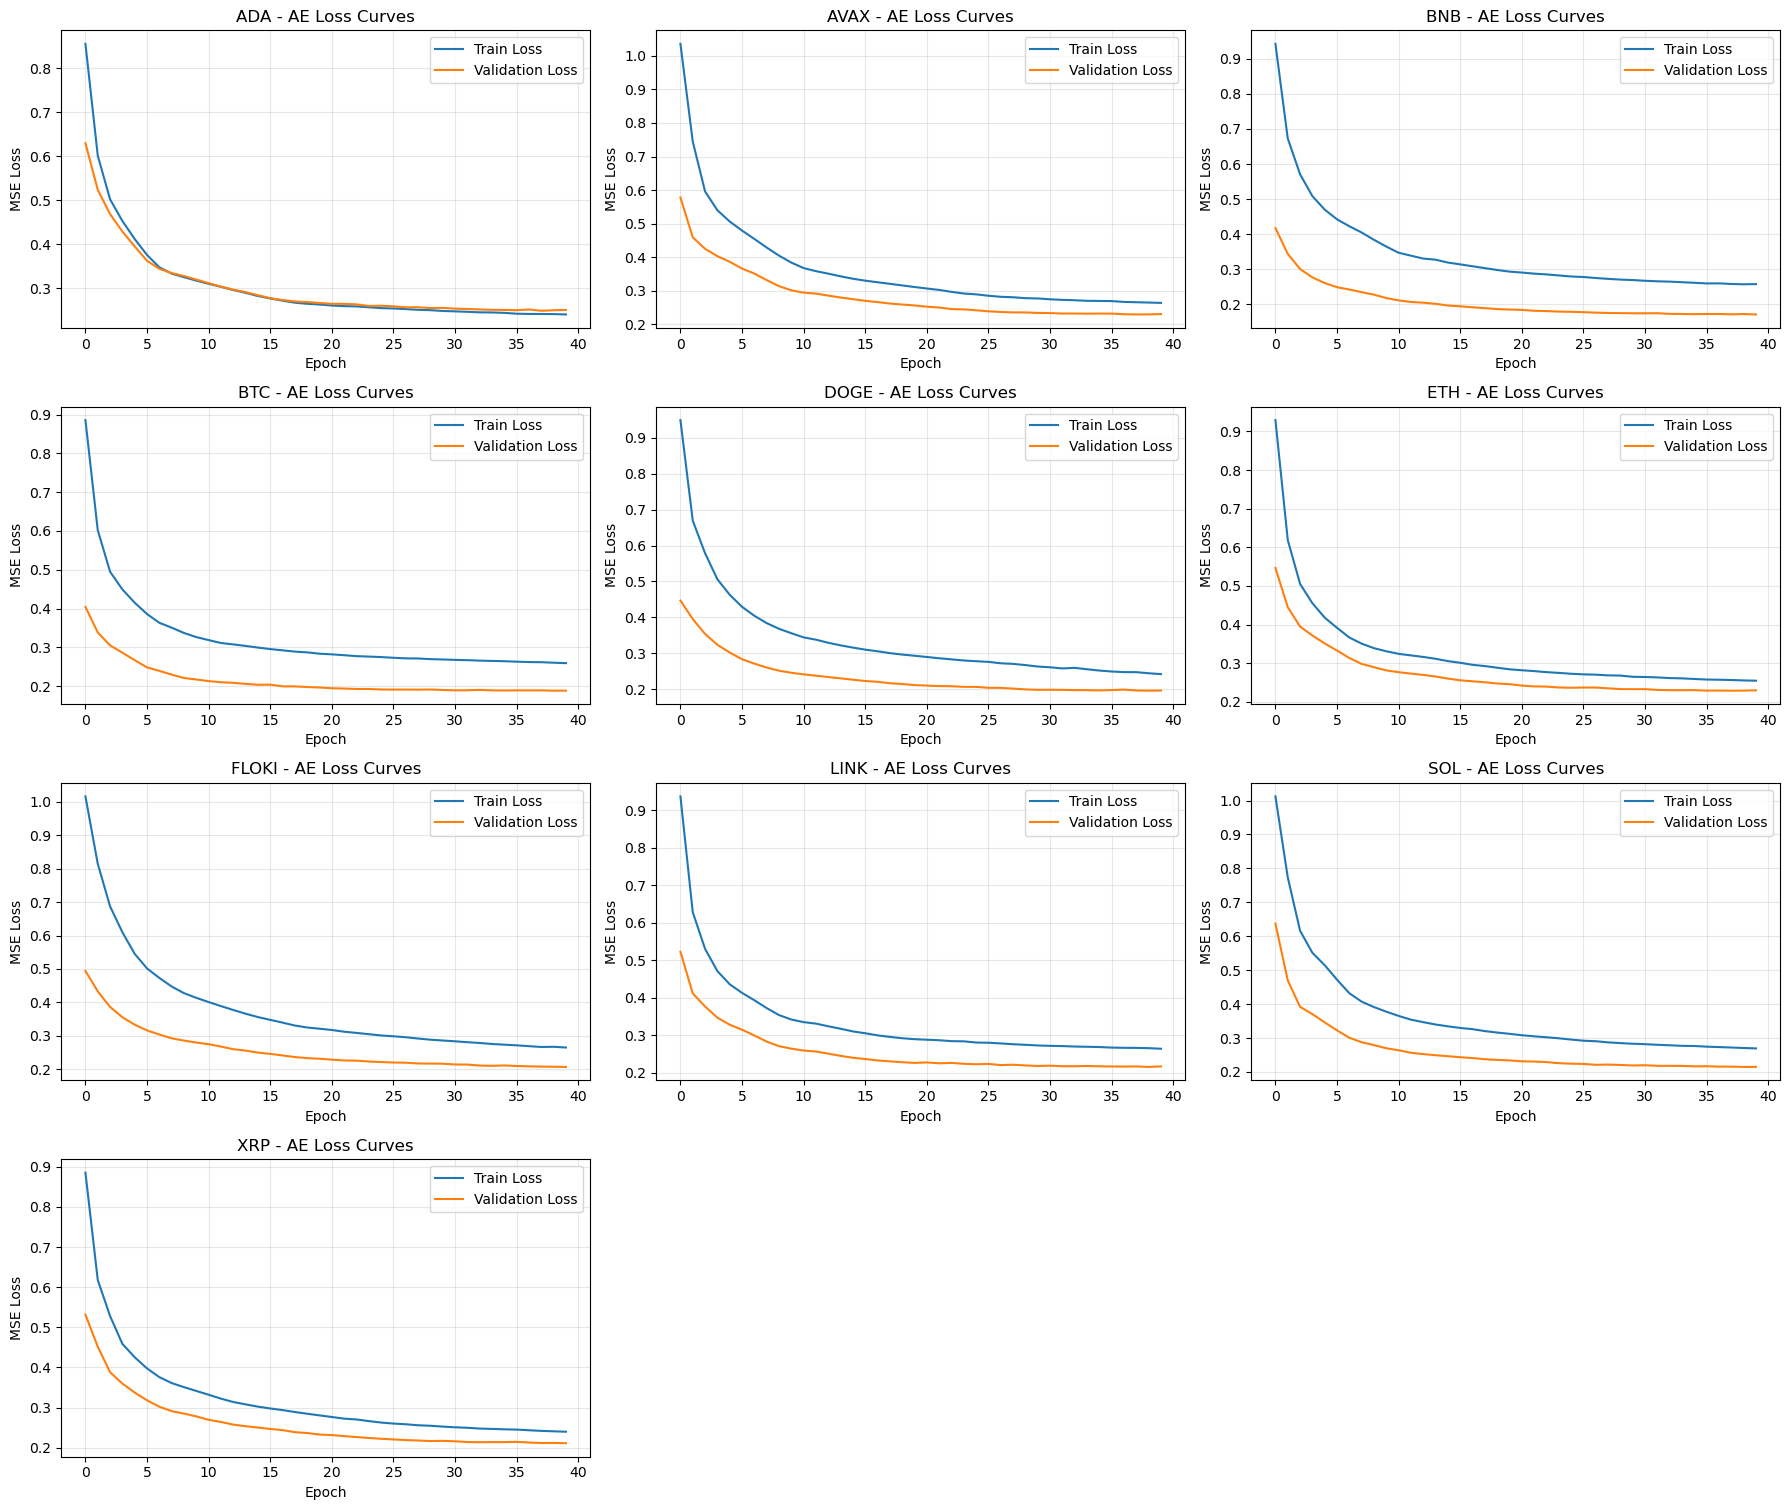

In [4]:
# Plot train/validation loss curves for each coin
coins = list(coin_results.keys())
if not coins:
    raise RuntimeError('No coin results available. Run previous cells first.')

n = len(coins)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3.8 * rows), squeeze=False)
axes = axes.flatten()

for i, coin in enumerate(coins):
    hist = coin_results[coin]['loss_history']
    ax = axes[i]
    ax.plot(hist['train_loss'], label='Train Loss')
    ax.plot(hist['val_loss'], label='Validation Loss')
    ax.set_title(f'{coin} - AE Loss Curves')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.grid(alpha=0.3)
    ax.legend()

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()



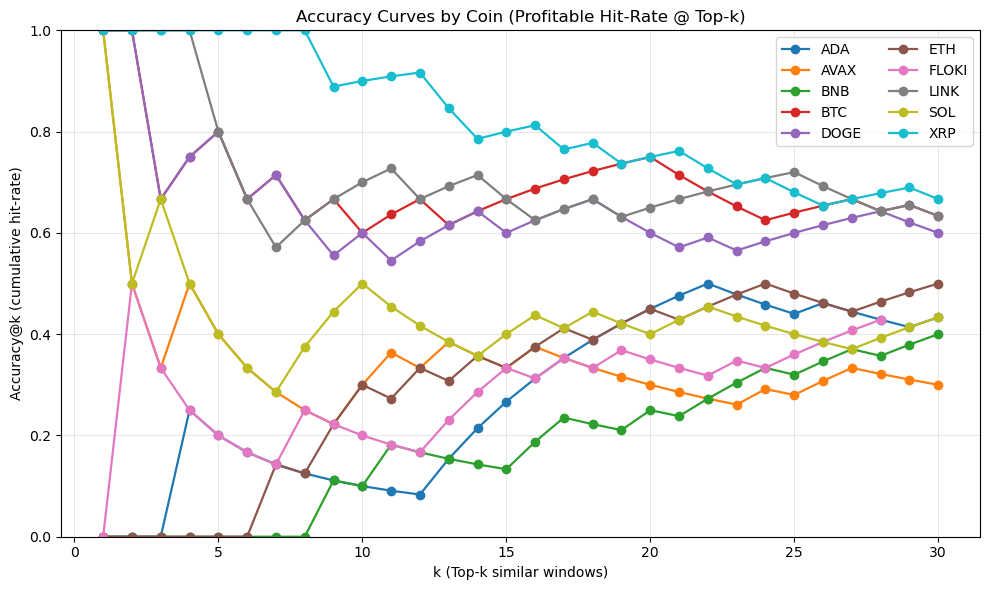

In [5]:
# Plot accuracy curves (cumulative profitable-hit rate vs top-k)
fig, ax = plt.subplots(figsize=(10, 6))

for coin, res in coin_results.items():
    curve = res['accuracy_curve']
    if len(curve) == 0:
        continue
    ax.plot(curve['k'], curve['accuracy'], marker='o', linewidth=1.6, label=coin)

ax.set_title('Accuracy Curves by Coin (Profitable Hit-Rate @ Top-k)')
ax.set_xlabel('k (Top-k similar windows)')
ax.set_ylabel('Accuracy@k (cumulative hit-rate)')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()



,coin,n_windows,final_train_loss,final_val_loss,n_evaluated,prob_profit,mean_profit,mean_loss,mean_max_drawdown
0,ADA,2988,0.240300,0.250370,30,0.433333,0.162847,-0.114779,-0.119120
1,AVAX,1942,0.263483,0.230061,30,0.300000,0.527240,-0.114908,-0.139721
2,BNB,2988,0.257411,0.170838,30,0.400000,0.088088,-0.046148,-0.058325
3,BTC,4137,0.259517,0.188619,30,0.633333,0.039508,-0.060878,-0.075303
4,DOGE,2988,0.242212,0.196564,30,0.600000,0.187686,-0.101957,-0.127075
5,ETH,2988,0.254794,0.229894,30,0.500000,0.120165,-0.121792,-0.132127
6,FLOKI,1613,0.265046,0.206925,28,0.428571,0.368954,-0.132089,-0.124776
7,LINK,2988,0.264409,0.217256,30,0.633333,0.145500,-0.181796,-0.124519
8,SOL,2105,0.269531,0.215078,30,0.433333,0.132604,-0.059333,-0.123095
9,XRP,2988,0.239806,0.211234,30,0.666667,0.183040,-0.027757,-0.067981


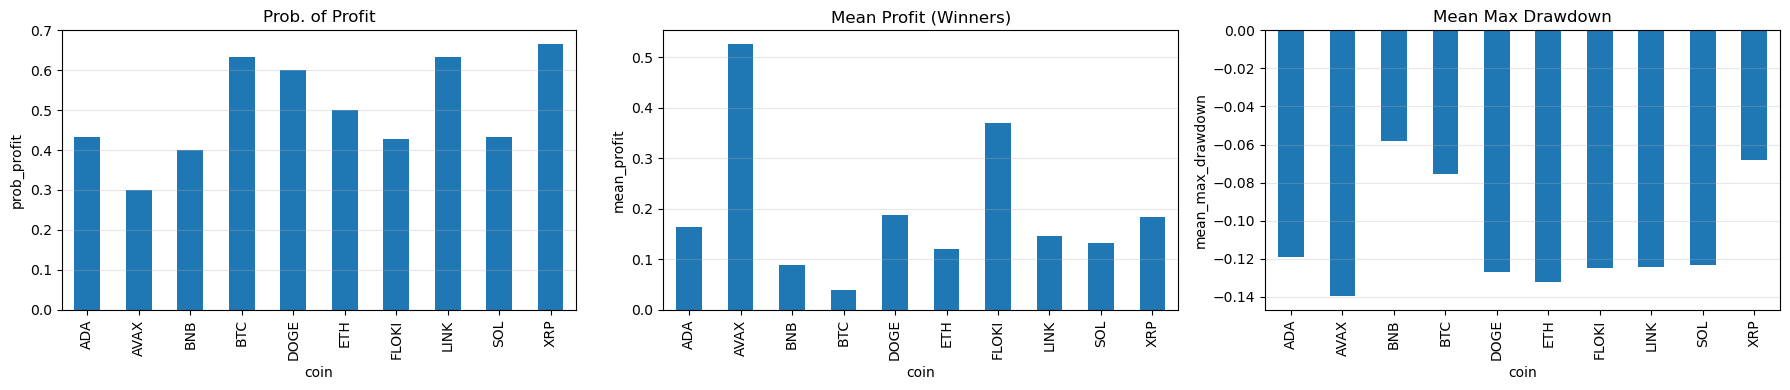

In [6]:
# Evaluation summary table + aggregate bars
display(summary_df)

plot_df = summary_df.copy().set_index('coin')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

plot_df['prob_profit'].plot(kind='bar', ax=axes[0], title='Prob. of Profit')
axes[0].set_ylabel('prob_profit')
axes[0].grid(axis='y', alpha=0.3)

plot_df['mean_profit'].plot(kind='bar', ax=axes[1], title='Mean Profit (Winners)')
axes[1].set_ylabel('mean_profit')
axes[1].grid(axis='y', alpha=0.3)

plot_df['mean_max_drawdown'].plot(kind='bar', ax=axes[2], title='Mean Max Drawdown')
axes[2].set_ylabel('mean_max_drawdown')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



## Nearest Neighbors Training and Evaluation

### Model Used
For regime matching, we use **k-Nearest Neighbors (sklearn `NearestNeighbors`)** on top of autoencoder latent embeddings.

### Structure and Pipeline
1. Build rolling windows from standardized feature vectors.
2. Train the autoencoder to produce latent embeddings.
3. Fit KNN on **training embeddings**.
4. For each validation window, retrieve nearest historical regimes and infer direction by majority vote.

### KNN Hyperparameters
- `metric`: `cosine` (primary), also evaluated with `euclidean`
- `k_max`: 30 (curves are computed for k=1..30)
- `train_frac`: 0.8 chronological split
- `horizon_days`: 14 for forward-return sign label
- `embargo_days`: 5 (used in original matcher logic)

### Where KNN is fit in the codebase
- KNN fit/retrieval: [`find_top_n_similar_windows` in `core/regime_detection/historical_matching.py`](../core/regime_detection/historical_matching.py#L228)
- Specifically: `NearestNeighbors(n_neighbors=top_n, metric=metric).fit(candidate_embeddings)`

### Evaluation in this section
- Validation **accuracy@k** curves (majority vote of top-k neighbors)
- Distance curves: average nearest-neighbor distance vs k
- Per-coin summary table (best accuracy, accuracy@1, fit time)



In [7]:
import time
from sklearn.neighbors import NearestNeighbors

NN_K_MAX = 30
NN_METRICS = ['cosine', 'euclidean']
NN_TRAIN_FRAC = 0.8
NN_HORIZON_DAYS = 14


def _forward_return_sign(close: np.ndarray, end_indices: np.ndarray, horizon_days: int) -> np.ndarray:
    # Label each window by sign of forward return over horizon_days.
    labels = np.full(len(end_indices), np.nan, dtype=float)
    n = len(close)
    for i, end_idx in enumerate(end_indices):
        start_idx = int(end_idx - 1)
        fwd_end = int(end_idx + horizon_days - 1)
        if start_idx < 0 or fwd_end >= n:
            continue
        r = (close[fwd_end] / close[start_idx]) - 1.0
        labels[i] = 1.0 if r > 0 else 0.0
    return labels


def _majority_vote_binary(y_neighbors: np.ndarray) -> float:
    ones = np.nansum(y_neighbors)
    zeros = np.sum(~np.isnan(y_neighbors)) - ones
    return 1.0 if ones >= zeros else 0.0


def evaluate_knn_for_coin(coin: str, df_raw: pd.DataFrame | None = None):
    # Train KNN on train embeddings and produce accuracy/distance curves on validation windows.
    if df_raw is None:
        df_raw = load_feature_data(MARKET_DATA_REPOSITORY.read_features(symbol=coin))
    if df_raw.empty:
        return None

    # Rebuild windows and embeddings for this coin
    df_scaled, _ = scale_features(df_raw)
    windows, window_end_indices = build_rolling_windows(df_scaled, match_window_days=MATCH_WINDOW_DAYS)
    if len(windows) < 50:
        return None

    model, _ = train_autoencoder_with_validation(
        windows=windows,
        latent_dim=LATENT_DIM,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        seed=SEED,
        train_frac=TRAIN_FRAC,
    )
    emb = compute_embeddings(model, windows)

    end_idx = np.asarray(window_end_indices, dtype=int)
    close = pd.to_numeric(df_raw['close'], errors='coerce').values
    y = _forward_return_sign(close, end_idx, horizon_days=NN_HORIZON_DAYS)

    split = int(len(emb) * NN_TRAIN_FRAC)
    split = min(max(split, 30), len(emb) - 10)

    X_train, X_val = emb[:split], emb[split:]
    y_train, y_val = y[:split], y[split:]

    valid_val_mask = ~np.isnan(y_val)
    if valid_val_mask.sum() < 20:
        return None

    X_val = X_val[valid_val_mask]
    y_val = y_val[valid_val_mask]

    metric_results = {}

    for metric in NN_METRICS:
        t0 = time.perf_counter()
        nn = NearestNeighbors(n_neighbors=NN_K_MAX, metric=metric)
        nn.fit(X_train)
        fit_ms = (time.perf_counter() - t0) * 1000.0

        distances, indices = nn.kneighbors(X_val, return_distance=True)

        acc = []
        avg_dist = []
        ks = np.arange(1, NN_K_MAX + 1)

        for k in ks:
            preds = []
            for i in range(len(X_val)):
                neigh_idx = indices[i, :k]
                y_neighbors = y_train[neigh_idx]
                y_neighbors = y_neighbors[~np.isnan(y_neighbors)]
                if len(y_neighbors) == 0:
                    preds.append(0.0)
                else:
                    preds.append(_majority_vote_binary(y_neighbors))
            preds = np.asarray(preds)
            acc.append(float((preds == y_val).mean()))
            avg_dist.append(float(np.mean(distances[:, :k])))

        metric_results[metric] = {
            'k': ks,
            'accuracy': np.asarray(acc),
            'avg_distance': np.asarray(avg_dist),
            'fit_ms': float(fit_ms),
            'best_accuracy': float(np.max(acc)),
            'best_k': int(ks[int(np.argmax(acc))]),
            'accuracy_at_1': float(acc[0]),
            'n_val': int(len(y_val)),
        }

    return metric_results



In [8]:
# Run KNN training/evaluation for all coins
knn_results = {}

if 'feature_frames' not in globals():
    feature_frames = load_feature_frames(COIN_SYMBOLS)

coins_for_knn = sorted(feature_frames.keys())
print(f'Found {len(coins_for_knn)} coins')

for coin in coins_for_knn:
    out = evaluate_knn_for_coin(coin, df_raw=feature_frames[coin])
    if out is None:
        print(f'Skipped {coin} (insufficient valid data)')
        continue
    knn_results[coin] = out
    print(f'Completed {coin}')

print(f'KNN done for {len(knn_results)} coins')



Found 10 coins
Completed ADA
Completed AVAX
Completed BNB
Completed BTC
Completed DOGE
Completed ETH
Completed FLOKI
Completed LINK
Completed SOL
Completed XRP
KNN done for 10 coins


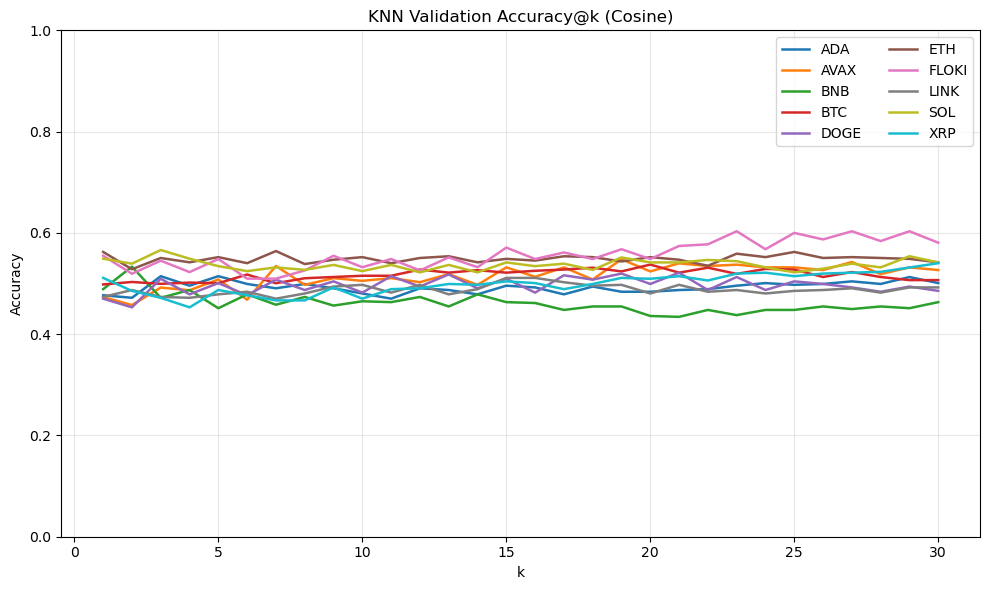

In [9]:
# Plot KNN accuracy@k curves (cosine)
if not knn_results:
    raise RuntimeError('No KNN results available. Run previous cell first.')

fig, ax = plt.subplots(figsize=(10, 6))
for coin, res in knn_results.items():
    curve = res['cosine']
    ax.plot(curve['k'], curve['accuracy'], linewidth=1.8, label=coin)

ax.set_title('KNN Validation Accuracy@k (Cosine)')
ax.set_xlabel('k')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()



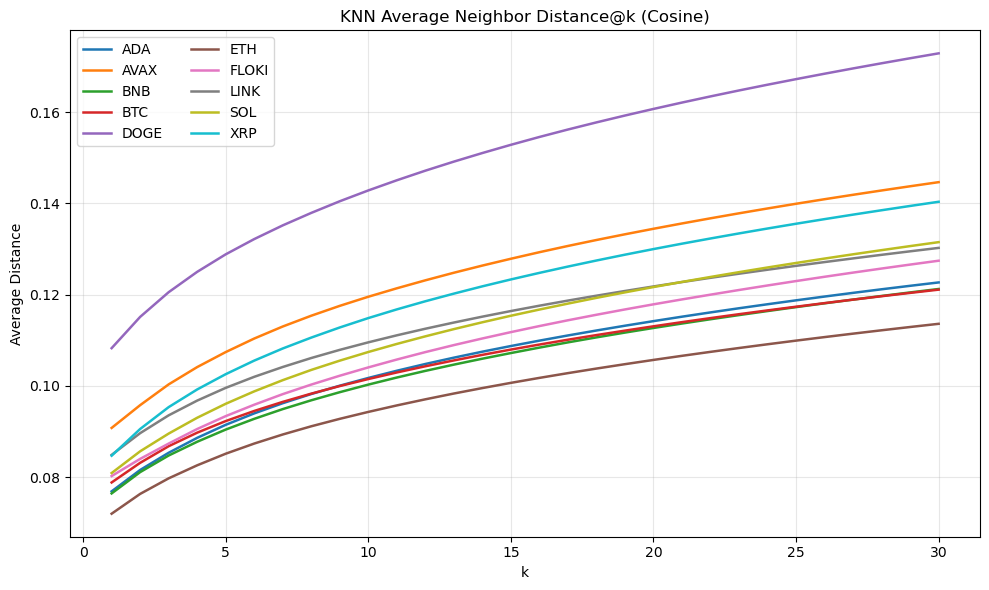

In [10]:
# Plot KNN average distance curves (cosine)
fig, ax = plt.subplots(figsize=(10, 6))
for coin, res in knn_results.items():
    curve = res['cosine']
    ax.plot(curve['k'], curve['avg_distance'], linewidth=1.8, label=coin)

ax.set_title('KNN Average Neighbor Distance@k (Cosine)')
ax.set_xlabel('k')
ax.set_ylabel('Average Distance')
ax.grid(alpha=0.3)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()



In [11]:
# KNN evaluation summary tables (cosine + euclidean)
rows = []
for coin, res in knn_results.items():
    for metric in NN_METRICS:
        m = res[metric]
        rows.append({
            'coin': coin,
            'metric': metric,
            'n_val': m['n_val'],
            'fit_ms': round(m['fit_ms'], 2),
            'accuracy_at_1': round(m['accuracy_at_1'], 4),
            'best_accuracy': round(m['best_accuracy'], 4),
            'best_k': m['best_k'],
        })

knn_summary_df = pd.DataFrame(rows).sort_values(['coin', 'metric']).reset_index(drop=True)
display(knn_summary_df)



,coin,metric,n_val,fit_ms,accuracy_at_1,best_accuracy,best_k
0,ADA,cosine,585,0.66,0.4769,0.5145,3
1,ADA,euclidean,585,0.35,0.5094,0.5368,25
2,AVAX,cosine,376,0.58,0.4734,0.5479,19
3,AVAX,euclidean,376,0.37,0.5372,0.5665,3
4,BNB,cosine,585,0.54,0.4889,0.5333,2
5,BNB,euclidean,585,0.61,0.4701,0.4701,1
6,BTC,cosine,815,0.65,0.4982,0.5374,20
7,BTC,euclidean,815,0.38,0.5129,0.5472,14
8,DOGE,cosine,585,0.61,0.4701,0.5214,21
9,DOGE,euclidean,585,0.35,0.5043,0.5077,7
